# NYC Airbnb 2019 — Data Cleaning & Exploratory Data Analysis

## Objective

The goal of this project is to clean and explore the NYC Airbnb 2019 dataset in order to understand the main characteristics of Airbnb listings in New York City.

The analysis focuses on:
- Data quality and missing values
- Price distribution and outliers
- Differences between NYC boroughs
- Room types and their prices
- Geographic distribution of listings
- Reviews and availability
- Relationships between numerical variables

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 2. Initial Data Exploration

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

Rows: 48,895
Columns: 16

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Initial observations

The dataset contains **48,895 listings and 16 columns**. Before analysing patterns, the next step is to inspect missing values, duplicates, data types, and potentially invalid values.

## 3. Data Cleaning

### 3.1 Missing Values

In [6]:
missing = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing[missing["missing_values"] > 0].sort_values(
    "missing_values",
    ascending=False
)

,missing_values,missing_percentage
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


In [7]:
same_missing_pattern = (
    df["last_review"].isna()
    == df["reviews_per_month"].isna()
).all()

zero_reviews_match = (
    (df["number_of_reviews"] == 0)
    == df["last_review"].isna()
).all()

print("last_review and reviews_per_month missing together:", same_missing_pattern)
print("number_of_reviews == 0 matches missing last_review:", zero_reviews_match)

last_review and reviews_per_month missing together: True
number_of_reviews == 0 matches missing last_review: True


#### Missing-value findings

- `last_review` and `reviews_per_month` are always `NaN` together.
- These missing values occur when `number_of_reviews == 0`, which makes sense because those listings have never received a review.
- Missing `reviews_per_month` values can therefore be replaced with `0`.
- Missing `last_review` values should remain missing because there is no review date to record.
- The small number of missing values in `name` and `host_name` are replaced with `"Unknown"`.

In [8]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

df.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### 3.2 Duplicate Rows

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Duplicated rows: {duplicate_count}")

Duplicated rows: 0


No duplicated rows were found in the dataset.

### 3.3 Validation and Outlier Inspection

In [10]:
print("Invalid latitude rows:",
      ((df["latitude"] < -90) | (df["latitude"] > 90)).sum())

print("Invalid longitude rows:",
      ((df["longitude"] < -180) | (df["longitude"] > 180)).sum())

print("Price equal to 0:", (df["price"] == 0).sum())
print("Availability equal to 0:", (df["availability_365"] == 0).sum())
print("Availability outside [0, 365]:",
      ((df["availability_365"] < 0) | (df["availability_365"] > 365)).sum())

Invalid latitude rows: 0
Invalid longitude rows: 0
Price equal to 0: 11
Availability equal to 0: 17533
Availability outside [0, 365]: 0


In [11]:
df[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.090910,112.781327
std,240.154170,20.510550,44.550582,1.597283,131.622289
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,0.000000
50%,106.000000,3.000000,5.000000,0.370000,45.000000
75%,175.000000,5.000000,24.000000,1.580000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,365.000000


In [12]:
print("Highest prices:")
display(df.nlargest(10, "price")[
    ["name", "neighbourhood_group", "room_type", "price"]
])

print("\nHighest minimum_nights:")
display(df.nlargest(10, "minimum_nights")[
    ["name", "neighbourhood_group", "minimum_nights", "price"]
])

Highest prices:


,name,neighbourhood_group,room_type,price
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Entire home/apt,7500



Highest minimum_nights:


,name,neighbourhood_group,minimum_nights,price
5767,Prime W. Village location 1 bdrm,Manhattan,1250,180
2854,Unknown,Manhattan,1000,400
13404,Historic Designer 2 Bed. Apartment,Manhattan,999,99
26341,Beautiful place in Brooklyn! #2,Brooklyn,999,79
38664,Shared Studio (females only),Manhattan,999,110
7355,Beautiful Fully Furnished 1 bed/bth,Queens,500,134
8014,Wonderful Large 1 bedroom,Manhattan,500,75
11193,Zen Room in Crown Heights Brooklyn,Brooklyn,500,50
14285,Peaceful apartment close to F/G,Brooklyn,500,45
47620,Williamsburg Apartment,Brooklyn,500,140


#### Data-quality findings

- Latitude and longitude values are within their globally valid ranges.
- There are **11 listings with `price == 0`**, which are suspicious values but are not automatically removed.
- `minimum_nights` contains extreme values, including values above 1,000 nights.
- **17,533 listings (about 35.9%) have `availability_365 == 0`**. A value of `0` is valid and should not be treated as missing.
- Extreme values are retained, while some visualizations use restricted ranges to make the main distribution easier to see.

## 4. Exploratory Data Analysis

### 4.1 Price Distribution

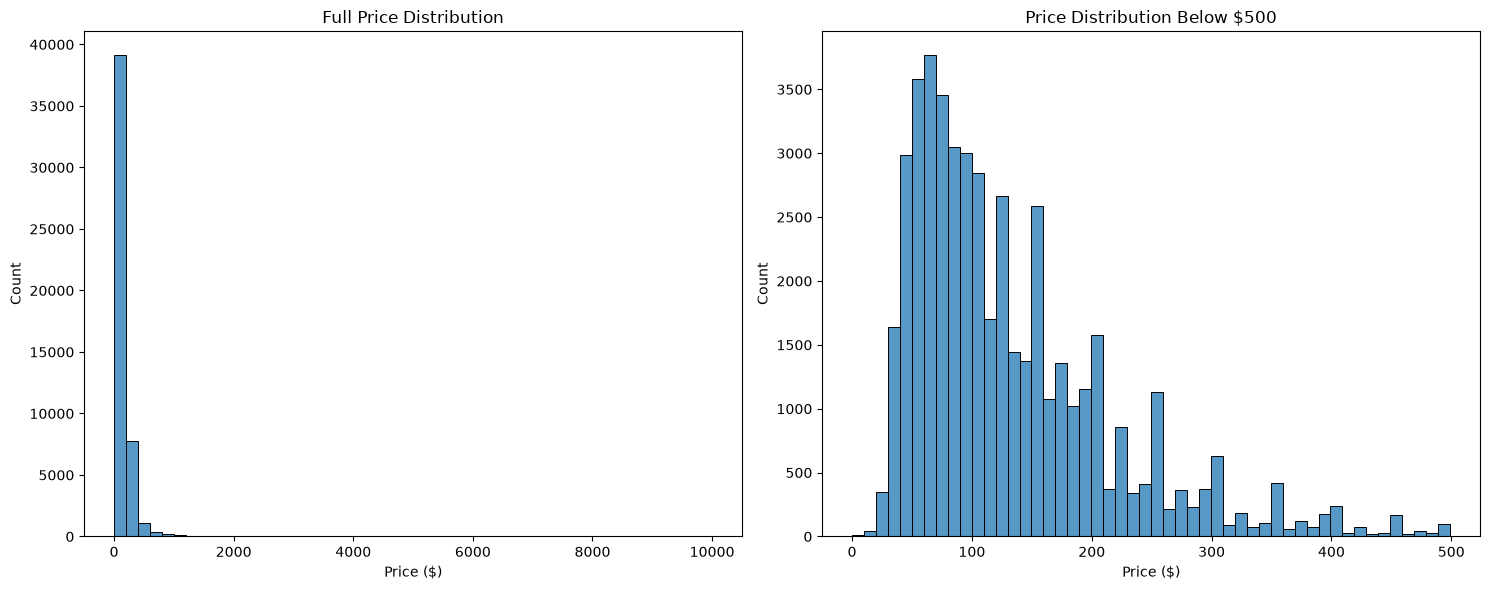

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x="price", bins=50, ax=axes[0])
axes[0].set_title("Full Price Distribution")
axes[0].set_xlabel("Price ($)")

sns.histplot(data=df[df["price"] < 500], x="price", bins=50, ax=axes[1])
axes[1].set_title("Price Distribution Below $500")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.show()

The full price distribution is strongly affected by a small number of very expensive listings. Restricting the visualization to prices below `$500` makes the distribution of the majority of listings easier to inspect.

### 4.2 Listings and Prices by Borough

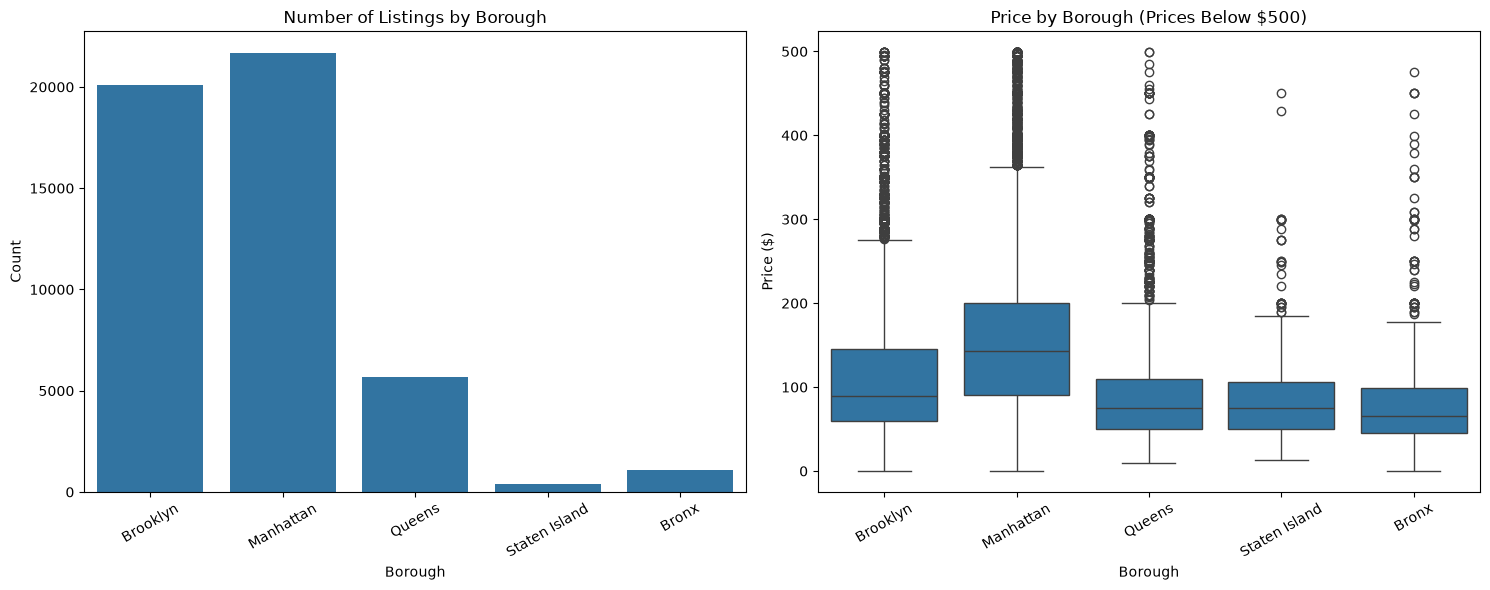

neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: median_price, dtype: float64

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df, x="neighbourhood_group", ax=axes[0])
axes[0].set_title("Number of Listings by Borough")
axes[0].set_xlabel("Borough")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=df[df["price"] < 500],
    x="neighbourhood_group",
    y="price",
    ax=axes[1]
)
axes[1].set_title("Price by Borough (Prices Below $500)")
axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Price ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

display(
    df.groupby("neighbourhood_group")["price"]
      .median()
      .sort_values(ascending=False)
      .rename("median_price")
)

The median-price comparison shows clear differences between boroughs. **Manhattan has the highest median price (`$150`)**, followed by Brooklyn (`$90`). Bronx has the lowest median price (`$65`).

### 4.3 Room Type Analysis

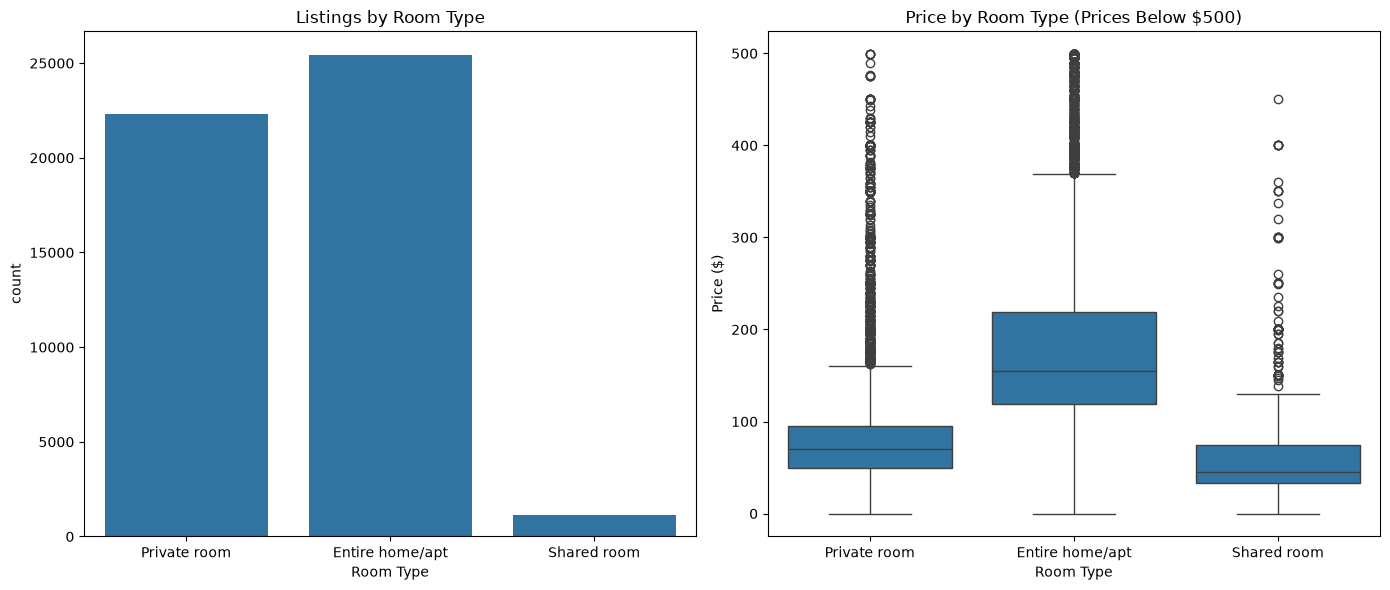

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: median_price, dtype: float64

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x="room_type", ax=axes[0])
axes[0].set_title("Listings by Room Type")
axes[0].set_xlabel("Room Type")

sns.boxplot(
    data=df[df["price"] < 500],
    x="room_type",
    y="price",
    ax=axes[1]
)
axes[1].set_title("Price by Room Type (Prices Below $500)")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

display(
    df.groupby("room_type")["price"]
      .median()
      .sort_values(ascending=False)
      .rename("median_price")
)

Room type is clearly associated with price. The median price is **`$160` for entire homes/apartments**, **`$70` for private rooms**, and **`$45` for shared rooms**.

### 4.4 Geographic Distribution

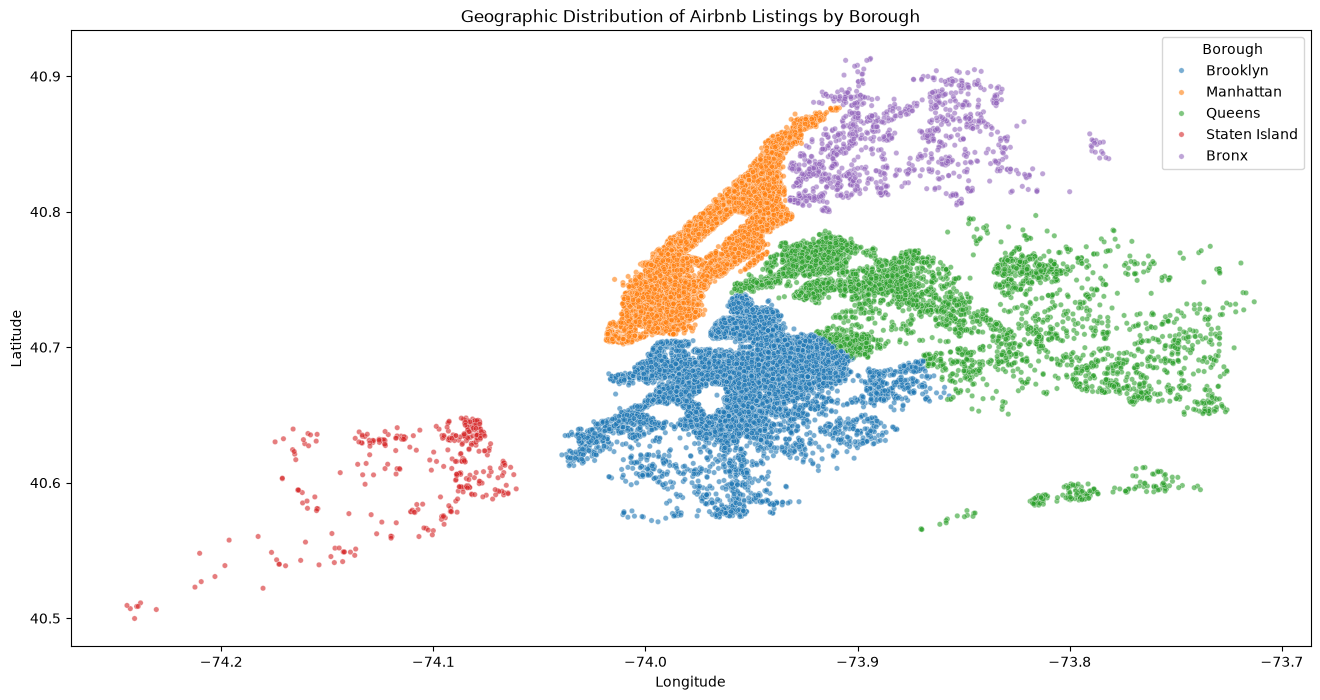

In [19]:
plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    alpha=0.6,
    s=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Airbnb Listings by Borough")
plt.legend(title="Borough")
plt.show()

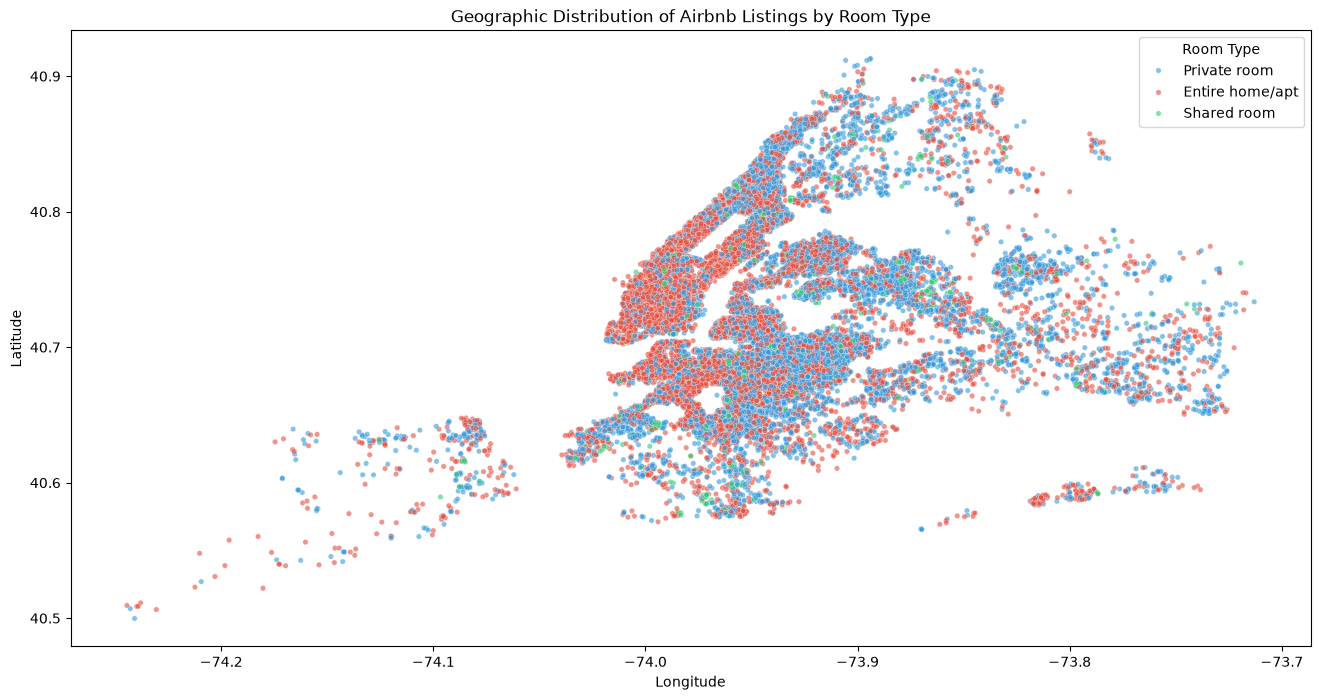

In [20]:
room_colors = {
    "Entire home/apt": "#E74C3C",
    "Private room": "#3498DB",
    "Shared room": "#2ECC71"
}

plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="room_type",
    palette=room_colors,
    alpha=0.6,
    s=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Airbnb Listings by Room Type")
plt.legend(title="Room Type")
plt.show()

The coordinate plots show that listings are geographically concentrated rather than evenly distributed across New York City. Colouring the points by borough and room type helps compare how listing categories are distributed spatially.

### 4.5 Reviews Analysis

In [21]:
df.nlargest(10, "number_of_reviews")[
    ["name", "price", "neighbourhood_group", "neighbourhood", "number_of_reviews"]
]

,name,price,neighbourhood_group,neighbourhood,number_of_reviews
11759,Room near JFK Queen Bed,47,Queens,Jamaica,629
2031,Great Bedroom in Manhattan,49,Manhattan,Harlem,607
2030,Beautiful Bedroom in Manhattan,49,Manhattan,Harlem,597
2015,Private Bedroom in Manhattan,49,Manhattan,Harlem,594
13495,Room Near JFK Twin Beds,47,Queens,Jamaica,576
10623,Steps away from Laguardia airport,46,Queens,East Elmhurst,543
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,99,Manhattan,Lower East Side,540
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,48,Queens,East Elmhurst,510
4870,Private brownstone studio Brooklyn,160,Brooklyn,Park Slope,488
471,LG Private Room/Family Friendly,60,Brooklyn,Bushwick,480


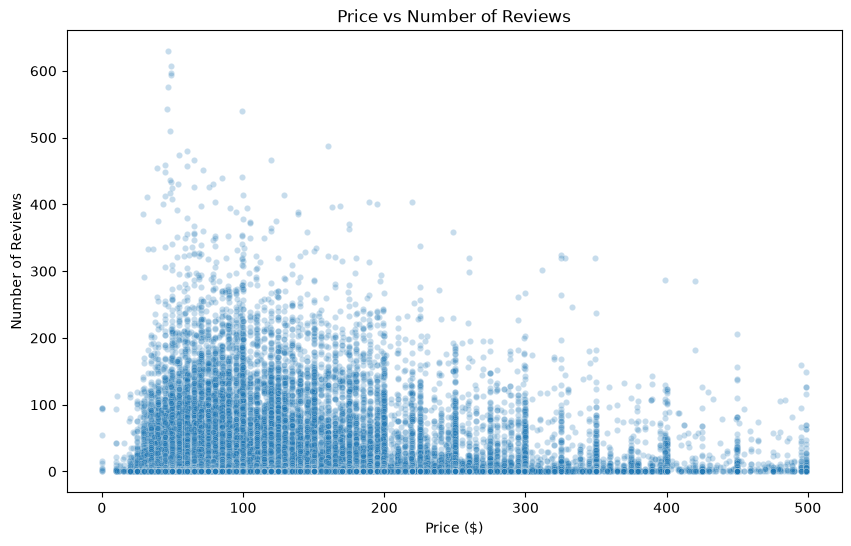

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[df["price"] < 500],
    x="price",
    y="number_of_reviews",
    alpha=0.25,
    s=20
)

plt.xlabel("Price ($)")
plt.ylabel("Number of Reviews")
plt.title("Price vs Number of Reviews")
plt.show()

The scatter plot does not suggest a strong linear relationship between listing price and the total number of reviews. Some of the most-reviewed listings are relatively inexpensive.

### 4.6 Availability Analysis

Listings with zero availability: 17,533
Percentage: 35.9%


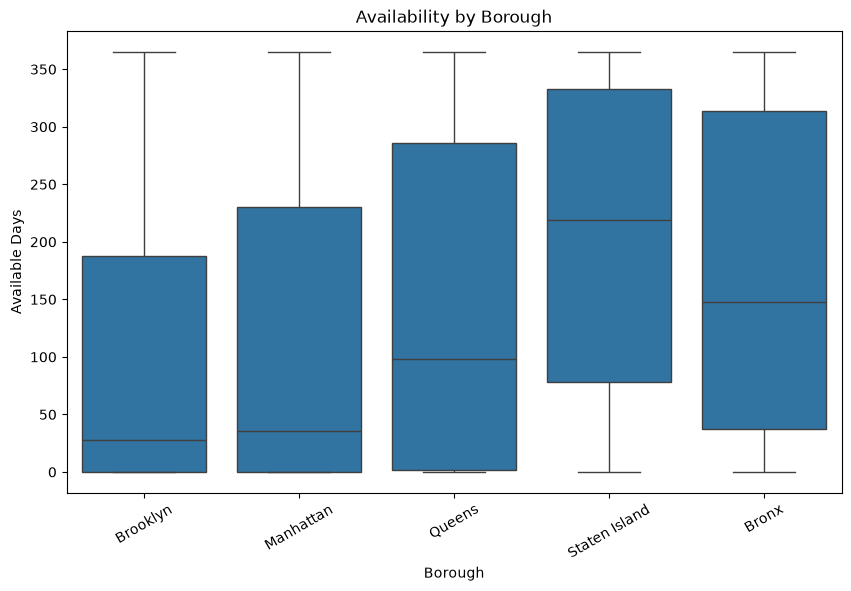

In [23]:
zero_availability = (df["availability_365"] == 0).sum()
zero_availability_pct = (df["availability_365"] == 0).mean() * 100

print(f"Listings with zero availability: {zero_availability:,}")
print(f"Percentage: {zero_availability_pct:.1f}%")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="availability_365"
)

plt.xlabel("Borough")
plt.ylabel("Available Days")
plt.title("Availability by Borough")
plt.xticks(rotation=30)
plt.show()

A substantial share of listings have no available days in the measured 365-day period. Because `0` is a valid value for this variable, these observations are kept rather than treated as missing data.

### 4.7 Correlation Analysis

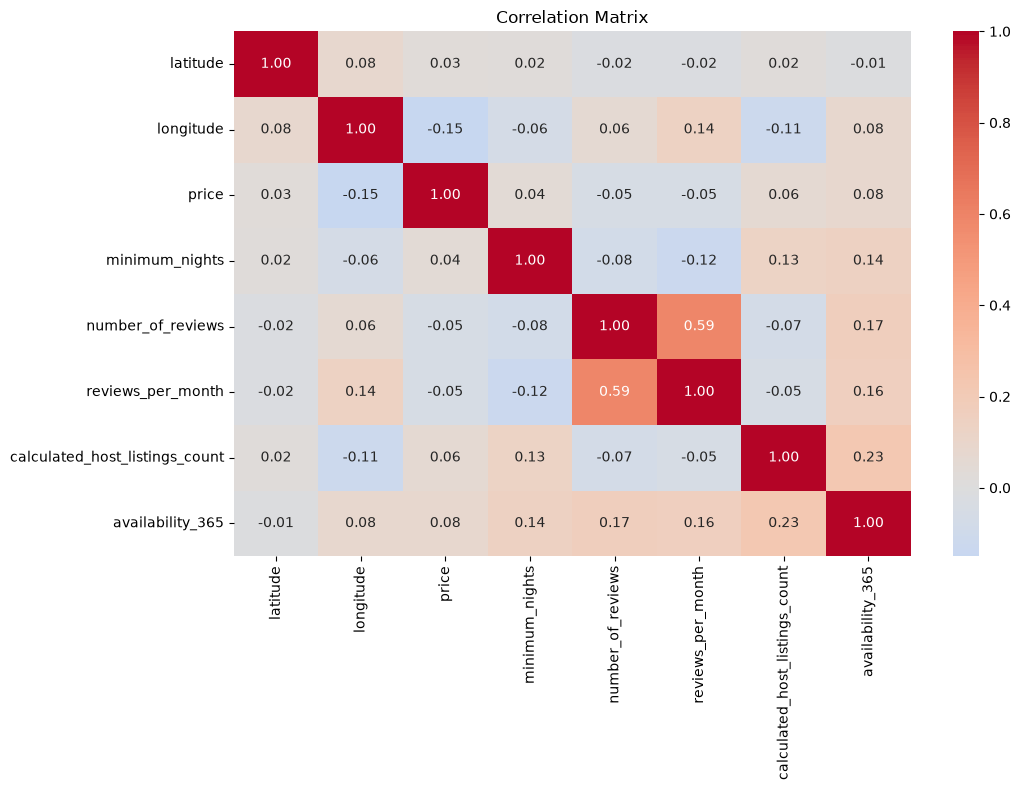

In [24]:
numeric = df.select_dtypes(include="number").drop(
    columns=["id", "host_id"]
)

corr = numeric.corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Correlation findings

- Most numerical variables have weak linear relationships.
- `number_of_reviews` and `reviews_per_month` show the strongest meaningful positive relationship in the original analysis (approximately `0.59`).
- `price` does not have a strong linear correlation with the other numerical variables.
- This suggests that categorical features such as `room_type`, `neighbourhood`, and `neighbourhood_group` may be more informative for understanding price differences.
- `id` and `host_id` are excluded because they are identifiers rather than meaningful quantitative features.
- Correlation should not be interpreted as causation.

## 5. Key Findings

- The dataset contains **48,895 Airbnb listings and 16 variables**.
- Missing review information is logically explained by listings with zero reviews rather than random missing data.
- There are no duplicated rows.
- The price distribution is strongly right-skewed and includes extreme outliers, reaching `$10,000`.
- **Manhattan has the highest median listing price (`$150`)**, while Bronx has the lowest (`$65`).
- **Entire homes/apartments have the highest median price (`$160`)**, compared with private rooms (`$70`) and shared rooms (`$45`).
- **17,533 listings (about 35.9%) have zero availability** within the 365-day period.
- Most numerical variables show weak linear correlations.

## 6. Conclusion

This project focused on cleaning and exploring the NYC Airbnb 2019 dataset rather than building a predictive model.

The analysis identified meaningful missing-value patterns, validated important variables, inspected unusual and extreme observations, and explored how price, room type, borough, reviews, availability, and geographic location are distributed.

The results show that Airbnb listings in New York City vary substantially across boroughs and room types, while price has relatively weak linear relationships with the other numerical variables.

The cleaned and explored dataset is now suitable for further analysis or for a separate machine-learning project.